# TBRGS – Traffic-Based Route Guidance System
## Part B: Machine Learning Pipeline

---

## Step 1: Load Data & Explore Structure

Goals:
- Load `Scats_Data_October_2006.xls`
- Inspect shape, columns, and data types
- No processing yet — observation only

In [1]:
#import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

FILE_PATH = 'Scats Data October 2006.xls'

# Read all sheet names first
xl = pd.ExcelFile(FILE_PATH, engine='xlrd')
print('=== Sheet names ===')
print(xl.sheet_names)

=== Sheet names ===
['Notes', 'Data', 'Summary Of Data']


In [2]:
# Load the 'Data' sheet — header is on row 2 (index 1)
df_raw = pd.read_excel(FILE_PATH, sheet_name='Data', engine='xlrd', header=1)

print('=== Shape ===')
print(f'Rows   : {df_raw.shape[0]}')
print(f'Columns: {df_raw.shape[1]}')

print('\n=== All column names ===')
print(df_raw.columns.tolist())

=== Shape ===
Rows   : 4192
Columns: 106

=== All column names ===
['SCATS Number', 'Location', 'CD_MELWAY', 'NB_LATITUDE', 'NB_LONGITUDE', 'HF VicRoads Internal', 'VR Internal Stat', 'VR Internal Loc', 'NB_TYPE_SURVEY', 'Date', 'V00', 'V01', 'V02', 'V03', 'V04', 'V05', 'V06', 'V07', 'V08', 'V09', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V79', 'V80', 'V81', 'V82', 'V83', 'V84', 'V85', 'V86', 'V87', 'V88', 'V89', 'V90', 'V91', 'V92', 'V93', 'V94', 'V95']


In [3]:
# Preview first 5 rows
df_raw.head()

,SCATS Number,Location,CD_MELWAY,NB_LATITUDE,NB_LONGITUDE,HF VicRoads Internal,VR Internal Stat,VR Internal Loc,NB_TYPE_SURVEY,Date,...,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95
0,970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-01 00:15:00,...,114,97,97,66,81,50,59,47,29,34
1,970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-02 00:15:00,...,111,102,107,114,80,60,62,48,44,26
2,970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-03 00:15:00,...,130,132,114,86,93,90,73,57,29,40
3,970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-04 00:15:00,...,115,113,132,101,113,90,78,66,52,44
4,970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-05 00:15:00,...,171,120,116,113,99,91,61,55,49,36


In [4]:
# Check data types and null values
print('=== Column data types ===')
print(df_raw.dtypes)

print('\n=== Null counts (only columns with nulls) ===')
null_counts = df_raw.isnull().sum()
print(null_counts[null_counts > 0])

=== Column data types ===
SCATS Number      int64
Location         object
CD_MELWAY        object
NB_LATITUDE     float64
NB_LONGITUDE    float64
                 ...   
V91               int64
V92               int64
V93               int64
V94               int64
V95               int64
Length: 106, dtype: object

=== Null counts (only columns with nulls) ===
Series([], dtype: int64)


In [5]:
# Summary statistics on key metadata columns
print('=== SCATS Number ===')
print(f'Unique sites : {df_raw["SCATS Number"].nunique()}')
print(f'Site list    : {sorted(df_raw["SCATS Number"].unique())}')

print('\n=== Date range ===')
print(f'Min date     : {df_raw["Date"].min()}')
print(f'Max date     : {df_raw["Date"].max()}')
print(f'Unique days  : {df_raw["Date"].nunique()}')

print('\n=== Locations (directions) per SCATS site ===')
loc_counts = df_raw.groupby('SCATS Number')['Location'].nunique()
print(loc_counts)
print(f'\nMean: {loc_counts.mean():.1f} | Min: {loc_counts.min()} | Max: {loc_counts.max()}')

=== SCATS Number ===
Unique sites : 40
Site list    : [np.int64(970), np.int64(2000), np.int64(2200), np.int64(2820), np.int64(2825), np.int64(2827), np.int64(2846), np.int64(3001), np.int64(3002), np.int64(3120), np.int64(3122), np.int64(3126), np.int64(3127), np.int64(3180), np.int64(3662), np.int64(3682), np.int64(3685), np.int64(3804), np.int64(3812), np.int64(4030), np.int64(4032), np.int64(4034), np.int64(4035), np.int64(4040), np.int64(4043), np.int64(4051), np.int64(4057), np.int64(4063), np.int64(4262), np.int64(4263), np.int64(4264), np.int64(4266), np.int64(4270), np.int64(4272), np.int64(4273), np.int64(4321), np.int64(4324), np.int64(4335), np.int64(4812), np.int64(4821)]

=== Date range ===
Min date     : 2006-10-01 00:15:00
Max date     : 2006-10-31 00:15:00
Unique days  : 31

=== Locations (directions) per SCATS site ===
SCATS Number
970     4
2000    4
2200    4
2820    2
2825    1
2827    4
2846    4
3001    4
3002    4
3120    4
3122    3
3126    3
3127    3
3180    

## From outputs above:

## ✅ What's clear:

- **4,192 rows × 106 columns** — reasonable (40 sites × ~3.5 directions × 31 days ≈ 4,340, close enough)
- **No NULL values** — looks clean, but needs closer inspection (nulls may be encoded as 0)
- **96 columns V00–V95** — as expected
- **Unusual date format:** `2006-10-01 00:15:00` — timestamp `00:15:00` is redundant, needs cleaning
- **40 sites, 31 days** — correct

## ⚠️ Points to note:

- Site **4040** has **6 directions** — unusually high, needs review
- Sites **2825, 4262, 4335** have only **1 direction** — limited data
- **Missing data = 0** per pandas — but uncertain, as value `0` may actually represent missing

---

**Next step:** Conduct a deeper inspection of data quality — specifically, determine whether `0` values truly represent "no vehicles" or are incorrectly encoded missing data. This step directly determines the missing data handling strategy.

In [6]:
# Isolate volume columns
vol_cols = [f'V{i:02d}' for i in range(96)]

# Check for zeros — are they real or missing data?
print('=== Zero value statistics in volume columns ===')
zero_counts = (df_raw[vol_cols] == 0).sum(axis=1)
print(f'Rows where ALL 96 intervals are zero : {(zero_counts == 96).sum()}')
print(f'Rows where > 50% intervals are zero  : {(zero_counts > 48).sum()}')
print(f'Rows where at least 1 zero           : {(zero_counts > 0).sum()}')
print(f'Total zero values across all volume  : {(df_raw[vol_cols] == 0).sum().sum()}')

print('\n=== Distribution of zero counts per row ===')
print(zero_counts.describe())

=== Zero value statistics in volume columns ===
Rows where ALL 96 intervals are zero : 0
Rows where > 50% intervals are zero  : 0
Rows where at least 1 zero           : 880
Total zero values across all volume  : 3910

=== Distribution of zero counts per row ===
count    4192.000000
mean        0.932729
std         3.719560
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        44.000000
dtype: float64


In [7]:
# Look at rows where more than half the day is zero
suspicious = df_raw[zero_counts > 48][['SCATS Number', 'Location', 'Date'] + vol_cols]
print(f'=== Rows with >50% zeros: {len(suspicious)} rows ===')
print(suspicious[['SCATS Number', 'Location', 'Date']].to_string())

=== Rows with >50% zeros: 0 rows ===
Empty DataFrame
Columns: [SCATS Number, Location, Date]
Index: []


In [8]:
# Inspect site 4040 — unusually has 6 directions
site_4040 = df_raw[df_raw['SCATS Number'] == 4040][['SCATS Number', 'Location', 'Date']].drop_duplicates('Location')
print('=== Site 4040 directions ===')
print(site_4040.to_string())

=== Site 4040 directions ===
      SCATS Number                      Location                Date
2417          4040   BURKE_RD N of RIVERSDALE_RD 2006-10-01 00:15:00
2448          4040   RIVERSDALE_RD E of BURKE_RD 2006-10-01 00:15:00
2479          4040  CAMBERWELL_RD SE of BURKE_RD 2006-10-01 00:15:00
2510          4040   BURKE_RD S of RIVERSDALE_RD 2006-10-01 00:15:00
2541          4040   RIVERSDALE_RD W of BURKE_RD 2006-10-01 00:15:00
2572          4040  CAMBERWELL_RD NW of BURKE_RD 2006-10-01 00:15:00


## From outputs above:

## ✅ Zero values — not a concern:

- No rows are ALL-zero or >50% zero
- Max only 44 zeros/row (out of 96 intervals) — likely genuine late-night periods with no traffic
- Average only ~0.93 zeros/row → data is fairly clean

## ✅ Site 4040 — completely normal:

- 6 directions because this is a **6-way intersection** (Burke Rd × Riversdale Rd × Camberwell Rd)
  — geographically valid, not a data anomaly

## ⚠️ Date format issue:

- `2006-10-01 00:15:00` — timestamp `00:15:00` is redundant, needs cleaning later

---

**Next step:** Verify whether zeros correspond to genuine late-night periods,
and get a quick overview of the overall traffic volume distribution.

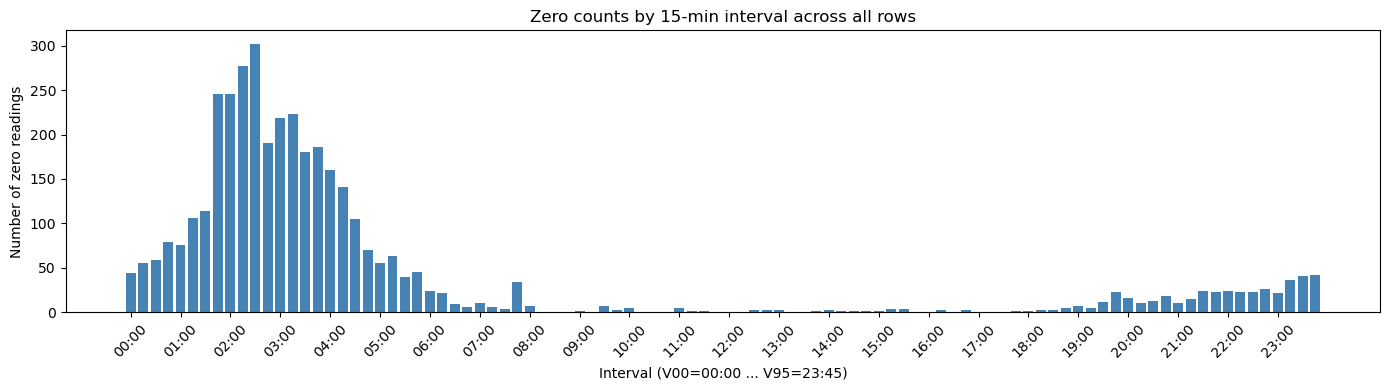

=== Top 10 intervals with most zeros ===
V10    302
V09    277
V07    245
V08    245
V13    223
V12    219
V11    191
V15    186
V14    180
V16    160
dtype: int64


In [9]:
# Check which time intervals tend to have zeros
# V00=00:00, V01=00:15, ..., V95=23:45
zero_by_interval = (df_raw[vol_cols] == 0).sum(axis=0)

plt.figure(figsize=(14, 4))
plt.bar(range(96), zero_by_interval.values, color='steelblue')
plt.xlabel('Interval (V00=00:00 ... V95=23:45)')
plt.ylabel('Number of zero readings')
plt.title('Zero counts by 15-min interval across all rows')
plt.xticks(range(0, 96, 4), [f'{i//4:02d}:00' for i in range(0, 96, 4)], rotation=45)
plt.tight_layout()
plt.show()

print('=== Top 10 intervals with most zeros ===')
print(zero_by_interval.sort_values(ascending=False).head(10))

=== Volume statistics (all intervals, all rows) ===
Min    : 0
Max    : 695
Mean   : 103.98
Median : 93.00
Std    : 86.72


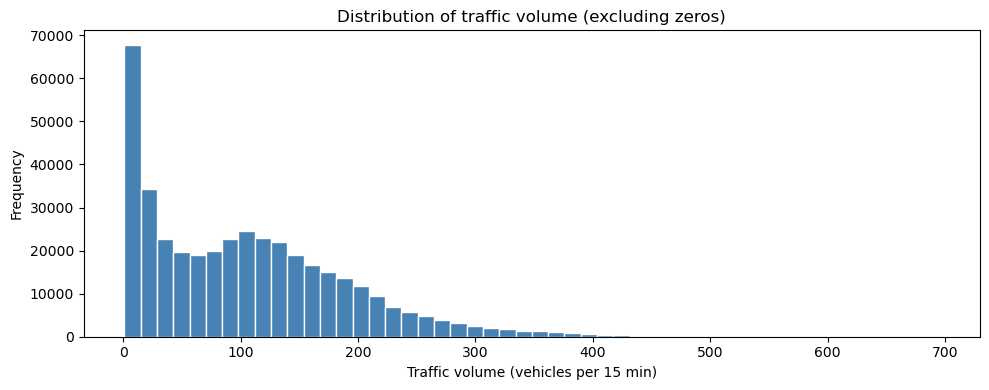

In [10]:
# Flatten all volume values to see the overall distribution
all_volumes = df_raw[vol_cols].values.flatten()

print('=== Volume statistics (all intervals, all rows) ===')
print(f'Min    : {all_volumes.min()}')
print(f'Max    : {all_volumes.max()}')
print(f'Mean   : {all_volumes.mean():.2f}')
print(f'Median : {np.median(all_volumes):.2f}')
print(f'Std    : {all_volumes.std():.2f}')

plt.figure(figsize=(10, 4))
plt.hist(all_volumes[all_volumes > 0], bins=50, color='steelblue', edgecolor='white')
plt.xlabel('Traffic volume (vehicles per 15 min)')
plt.ylabel('Frequency')
plt.title('Distribution of traffic volume (excluding zeros)')
plt.tight_layout()
plt.show()

## From outputs above:

## 📊 Zero pattern (Chart 1):

- Zeros are most concentrated in **V07–V16 (1:45 AM – 4:00 AM)** — entirely expected, genuine late-night low-traffic periods
- Almost no zeros after 7:00 AM → zeros reflect reality, not missing data
- ✅ **Conclusion:** No need to handle zeros — valid data

## 📊 Volume distribution (Chart 2):

- Range: **0 → 695 vehicles/15 min**
- Mean ~104, Median ~93 → **right-skewed** (most intervals have low-to-moderate volume)
- Max 695 vehicles/15 min = ~2,780 vehicles/hour — reasonable for urban roads
- Distribution shows **2 minor peaks around 50–150** → suggests a peak-hour pattern

## ✅ Data quality conclusion:

Data is fairly clean — no complex missing value handling required.

---

**Next step:** Fix the date format and reshape data from wide format (V00–V95)
to long format (datetime + volume) — the most critical step before model training.

In [11]:
# Fix the date column — strip the time component (00:15:00 is an artifact)
df_raw['Date'] = pd.to_datetime(df_raw['Date']).dt.date
df_raw['Date'] = pd.to_datetime(df_raw['Date'])

print('=== Date column after fix ===')
print(df_raw['Date'].head(5))
print(f'dtype: {df_raw["Date"].dtype}')

=== Date column after fix ===
0   2006-10-01
1   2006-10-02
2   2006-10-03
3   2006-10-04
4   2006-10-05
Name: Date, dtype: datetime64[ns]
dtype: datetime64[ns]


In [12]:
# Build a time offset mapping: V00 = 00:00, V01 = 00:15, ..., V95 = 23:45
time_offsets = {f'V{i:02d}': pd.Timedelta(minutes=15 * i) for i in range(96)}

# Melt from wide to long format
df_long = df_raw.melt(
    id_vars=['SCATS Number', 'Location', 'NB_LATITUDE', 'NB_LONGITUDE', 'Date'],
    value_vars=vol_cols,
    var_name='Interval',
    value_name='Volume'
)

# Reconstruct full datetime = Date + time offset
df_long['Datetime'] = df_long['Date'] + df_long['Interval'].map(time_offsets)

# Drop helper columns, sort
df_long = df_long.drop(columns=['Date', 'Interval'])
df_long = df_long.sort_values(['SCATS Number', 'Location', 'Datetime']).reset_index(drop=True)

print('=== Long format shape ===')
print(f'Rows: {len(df_long):,}')
print(f'Cols: {df_long.columns.tolist()}')
print('\n=== First 10 rows ===')
print(df_long.head(10).to_string())

=== Long format shape ===
Rows: 402,432
Cols: ['SCATS Number', 'Location', 'NB_LATITUDE', 'NB_LONGITUDE', 'Volume', 'Datetime']

=== First 10 rows ===
   SCATS Number                         Location  NB_LATITUDE  NB_LONGITUDE  Volume            Datetime
0           970  HIGH STREET_RD E of WARRIGAL_RD    -37.86735     145.09195      37 2006-10-01 00:00:00
1           970  HIGH STREET_RD E of WARRIGAL_RD    -37.86735     145.09195      30 2006-10-01 00:15:00
2           970  HIGH STREET_RD E of WARRIGAL_RD    -37.86735     145.09195      26 2006-10-01 00:30:00
3           970  HIGH STREET_RD E of WARRIGAL_RD    -37.86735     145.09195      29 2006-10-01 00:45:00
4           970  HIGH STREET_RD E of WARRIGAL_RD    -37.86735     145.09195      14 2006-10-01 01:00:00
5           970  HIGH STREET_RD E of WARRIGAL_RD    -37.86735     145.09195      20 2006-10-01 01:15:00
6           970  HIGH STREET_RD E of WARRIGAL_RD    -37.86735     145.09195      14 2006-10-01 01:30:00
7           970  

In [13]:
# Verify: one site+location should have 31 days × 96 intervals = 2,976 rows
sample = df_long[
    (df_long['SCATS Number'] == 970) &
    (df_long['Location'] == 'WARRIGAL_RD N of HIGH STREET_RD')
]
print('=== Sanity check: site 970, direction N ===')
print(f'Expected rows : 31 × 96 = {31*96}')
print(f'Actual rows   : {len(sample)}')
print(f'\nDatetime range: {sample["Datetime"].min()} → {sample["Datetime"].max()}')
print(f'\nVolume sample:\n{sample["Volume"].head(10).to_string()}')

=== Sanity check: site 970, direction N ===
Expected rows : 31 × 96 = 2976
Actual rows   : 2976

Datetime range: 2006-10-01 00:00:00 → 2006-10-31 23:45:00

Volume sample:
5856    86
5857    83
5858    52
5859    58
5860    59
5861    44
5862    31
5863    37
5864    30
5865    24


In [14]:
# Verify row counts for ALL site+location combinations
expected_rows = 31 * 96  # 2,976 per site+location

counts = df_long.groupby(['SCATS Number', 'Location']).size()

print(f'=== Full sanity check: all {len(counts)} site+location combinations ===')
print(f'Expected rows each : {expected_rows}')
print(f'All match expected : {(counts == expected_rows).all()}')

# Show any that do NOT match
mismatches = counts[counts != expected_rows]
if len(mismatches) > 0:
    print(f'\n⚠️  Mismatches found: {len(mismatches)}')
    print(mismatches)
else:
    print('\n✅ All combinations have exactly 2,976 rows — data is complete!')

=== Full sanity check: all 139 site+location combinations ===
Expected rows each : 2976
All match expected : False

⚠️  Mismatches found: 35
SCATS Number  Location                       
970           HIGH STREET_RD W of WARRIGAL_RD    2880
2000          BURWOOD_HWY E of WARRIGAL_RD       2784
              TOORAK_RD W of WARRIGAL_RD         2784
              WARRIGAL_RD N of TOORAK_RD         2688
              WARRIGAL_RD S of BURWOOD_HWY       2688
2820          PRINCESS_ST S of CHANDLER_HWY      2880
3001          CHURCH_ST SW of BARKERS_RD          192
3002          BARKERS_RD E of DENMARK_ST         2496
              BARKERS_RD W of DENMARK_ST         2496
              DENMARK_ST N of BARKERS_RD         2496
              POWER_ST S of BARKERS_RD           2496
3127          BALWYN_RD N of CANTERBURY_RD       2496
              CANTERBURY_RD E of BALWYN_RD       2496
              CANTERBURY_RD W of BALWYN_RD       2496
3682          RIVERSDALE_RD E OF WARRIGAL_RD     2784
   

## From output above:

## 🔍 Pattern mismatches:

| Pattern | Example | Cause |
|---|---|---|
| `2880` = 31×96 - 96 | 970, 2820... | Missing **1 day** |
| `2784` = 31×96 - 192 | 2000, 3682... | Missing **2 days** |
| `2496` = 31×96 - 480 | 3001, 3002... | Missing **5 days** |
| `2112` = 31×96 - 864 | 3685, 4264 | Missing **9 days** |
| `192` = 2×96 | 3001 CHURCH_ST | Only **2 days** of data — nearly unusable |
| `5952` = **62×96** | 4335 | **Duplicated!** — data from **2 locations** merged together |

---

⚠️ **Most critical issue:** Site **4335** has 5,952 rows = double the expected count
→ duplicate data confirmed, requires immediate investigation.

In [15]:
# --- Investigate site 4335 duplicate ---
site_4335 = df_long[df_long['SCATS Number'] == 4335]
print('=== Site 4335 - unique locations ===')
print(site_4335['Location'].unique())
print(f'\nRows per location:')
print(site_4335.groupby('Location').size())

print('\n=== Check for duplicate Datetime entries ===')
dupes = site_4335[site_4335.duplicated(subset=['SCATS Number', 'Location', 'Datetime'], keep=False)]
print(f'Duplicate rows: {len(dupes)}')
if len(dupes) > 0:
    print(dupes[['SCATS Number', 'Location', 'Datetime', 'Volume']].head(10).to_string())

=== Site 4335 - unique locations ===
['HIGH_ST NE of CHARLES_ST']

Rows per location:
Location
HIGH_ST NE of CHARLES_ST    5952
dtype: int64

=== Check for duplicate Datetime entries ===
Duplicate rows: 5952
        SCATS Number                  Location            Datetime  Volume
377088          4335  HIGH_ST NE of CHARLES_ST 2006-10-01 00:00:00      24
377089          4335  HIGH_ST NE of CHARLES_ST 2006-10-01 00:00:00      66
377090          4335  HIGH_ST NE of CHARLES_ST 2006-10-01 00:15:00      29
377091          4335  HIGH_ST NE of CHARLES_ST 2006-10-01 00:15:00      56
377092          4335  HIGH_ST NE of CHARLES_ST 2006-10-01 00:30:00      28
377093          4335  HIGH_ST NE of CHARLES_ST 2006-10-01 00:30:00      55
377094          4335  HIGH_ST NE of CHARLES_ST 2006-10-01 00:45:00      28
377095          4335  HIGH_ST NE of CHARLES_ST 2006-10-01 00:45:00      52
377096          4335  HIGH_ST NE of CHARLES_ST 2006-10-01 01:00:00      33
377097          4335  HIGH_ST NE of CHARLE

In [16]:
# Find which specific days are missing for each mismatched combination
all_dates = pd.date_range('2006-10-01', '2006-10-31', freq='D')

mismatch_sites = [
    (970,  'HIGH STREET_RD W of WARRIGAL_RD'),
    (3001, 'CHURCH_ST SW of BARKERS_RD'),
    (4335, 'HIGH_ST NE of CHARLES_ST'),
]

for scats, loc in mismatch_sites:
    subset = df_long[(df_long['SCATS Number'] == scats) & (df_long['Location'] == loc)]
    present_dates = subset['Datetime'].dt.normalize().unique()
    missing_dates = [d for d in all_dates if d not in present_dates]
    print(f'\n=== SCATS {scats} | {loc} ===')
    print(f'Present days: {len(present_dates)} | Missing days: {len(missing_dates)}')
    if missing_dates:
        print(f'Missing: {[str(d.date()) for d in missing_dates]}')


=== SCATS 970 | HIGH STREET_RD W of WARRIGAL_RD ===
Present days: 30 | Missing days: 1
Missing: ['2006-10-04']

=== SCATS 3001 | CHURCH_ST SW of BARKERS_RD ===
Present days: 2 | Missing days: 29
Missing: ['2006-10-01', '2006-10-04', '2006-10-05', '2006-10-06', '2006-10-07', '2006-10-08', '2006-10-09', '2006-10-10', '2006-10-11', '2006-10-12', '2006-10-13', '2006-10-14', '2006-10-15', '2006-10-16', '2006-10-17', '2006-10-18', '2006-10-19', '2006-10-20', '2006-10-21', '2006-10-22', '2006-10-23', '2006-10-24', '2006-10-25', '2006-10-26', '2006-10-27', '2006-10-28', '2006-10-29', '2006-10-30', '2006-10-31']

=== SCATS 4335 | HIGH_ST NE of CHARLES_ST ===
Present days: 31 | Missing days: 0


## From outputs above:

## 🔍 Site 4335 — duplicate with 2 different Volumes at the same Datetime:

- `00:00:00` → Volume 24 and 66
- `00:15:00` → Volume 29 and 56
- This is **not a reshape error** — the source file already contains **2 different rows**
  with the same site+location+date but different volumes
- Need to review the source file to understand why

## ⚠️ Site 3001 CHURCH_ST — only 2 days of data, nearly unusable for training → should be dropped

---

Before deciding how to handle, need to inspect site 4335 in the source file.

In [17]:
# Check site 4335 in the original raw dataframe
raw_4335 = df_raw[df_raw['SCATS Number'] == 4335]

print('=== Site 4335 in raw data ===')
print(f'Rows in df_raw : {len(raw_4335)}')
print(f'Unique Location: {raw_4335["Location"].unique()}')
print(f'Unique Dates   : {raw_4335["Date"].nunique()}')

# Show all rows with their first few volume columns
print('\n=== All rows (metadata + first 4 volume cols) ===')
print(raw_4335[['SCATS Number', 'Location', 'Date', 'V00', 'V01', 'V02', 'V03']].to_string())

=== Site 4335 in raw data ===
Rows in df_raw : 62
Unique Location: ['HIGH_ST NE of CHARLES_ST']
Unique Dates   : 31

=== All rows (metadata + first 4 volume cols) ===
      SCATS Number                  Location       Date  V00  V01  V02  V03
3928          4335  HIGH_ST NE of CHARLES_ST 2006-10-01   24   29   28   28
3929          4335  HIGH_ST NE of CHARLES_ST 2006-10-02    4    9   15    5
3930          4335  HIGH_ST NE of CHARLES_ST 2006-10-03   14    8    5    7
3931          4335  HIGH_ST NE of CHARLES_ST 2006-10-04   10    5    8   11
3932          4335  HIGH_ST NE of CHARLES_ST 2006-10-05   11   10   10    6
3933          4335  HIGH_ST NE of CHARLES_ST 2006-10-06   16   12   20   11
3934          4335  HIGH_ST NE of CHARLES_ST 2006-10-07   39   31   23   31
3935          4335  HIGH_ST NE of CHARLES_ST 2006-10-08   26   37   25   30
3936          4335  HIGH_ST NE of CHARLES_ST 2006-10-09   12    6    8    6
3937          4335  HIGH_ST NE of CHARLES_ST 2006-10-10    2    8    3   

In [18]:
# Missing day summary for all mismatched sites
all_dates = pd.date_range('2006-10-01', '2006-10-31', freq='D')

mismatch_combos = df_long.groupby(['SCATS Number', 'Location']).size()
mismatch_combos = mismatch_combos[mismatch_combos != 31 * 96]

print(f'=== Missing days report for all {len(mismatch_combos)} mismatched combinations ===\n')

summary = []
for (scats, loc), row_count in mismatch_combos.items():
    subset = df_long[
        (df_long['SCATS Number'] == scats) &
        (df_long['Location'] == loc)
    ]
    present_days = subset['Datetime'].dt.normalize().unique()
    n_missing = 31 - len(present_days)
    pct_missing = n_missing / 31 * 100
    summary.append({
        'SCATS': scats,
        'Location': loc,
        'Present days': len(present_days),
        'Missing days': n_missing,
        'Missing %': round(pct_missing, 1)
    })

df_summary = pd.DataFrame(summary).sort_values('Missing %', ascending=False)
print(df_summary.to_string(index=False))

=== Missing days report for all 35 mismatched combinations ===

 SCATS                        Location  Present days  Missing days  Missing %
  3001      CHURCH_ST SW of BARKERS_RD             2            29       93.5
  3685    WARRIGAL_RD S of HIGHBURY_RD            22             9       29.0
  4264   GLENFERRIE_RD S of BURWOOD_RD            22             9       29.0
  4812         SWAN_ST NE of MADDEN_GV            26             5       16.1
  4812          MADDEN_GV S OF SWAN_ST            26             5       16.1
  4263        POWER_ST S of BURWOOD_RD            26             5       16.1
  3002      DENMARK_ST N of BARKERS_RD            26             5       16.1
  3002        POWER_ST S of BARKERS_RD            26             5       16.1
  3127    CANTERBURY_RD W of BALWYN_RD            26             5       16.1
  3002      BARKERS_RD W of DENMARK_ST            26             5       16.1
  3002      BARKERS_RD E of DENMARK_ST            26             5       16.1


## Step 2: Data Cleaning

Steps:
1. Fix site 4335 — average the 2 duplicate rows per day
2. Remove site 3001 CHURCH_ST (93.5% missing)
3. Interpolate missing days using same-weekday average for all other sites

In [19]:
# Site 4335 has 2 detectors at slightly different coordinates
# Fix: group by SCATS Number, Location, Datetime only — average both Volume and coordinates
df_4335_fixed = (
    df_long[df_long['SCATS Number'] == 4335]
    .groupby(['SCATS Number', 'Location', 'Datetime'], as_index=False)
    [['NB_LATITUDE', 'NB_LONGITUDE', 'Volume']]
    .mean()
)
df_4335_fixed['Volume'] = df_4335_fixed['Volume'].round().astype(int)

# Rebuild df_clean from df_long
df_clean = df_long[df_long['SCATS Number'] != 4335].copy()
df_clean = pd.concat([df_clean, df_4335_fixed], ignore_index=True)

print(f'=== Site 4335 after fix ===')
print(f'Rows before : {len(df_long[df_long["SCATS Number"] == 4335])}')
print(f'Rows after  : {len(df_clean[df_clean["SCATS Number"] == 4335])}')
print(f'Expected    : {31 * 96}')

=== Site 4335 after fix ===
Rows before : 5952
Rows after  : 2976
Expected    : 2976


In [20]:
# Drop site 3001 CHURCH_ST SW of BARKERS_RD — only 2 days of data (93.5% missing)
mask = (
    (df_clean['SCATS Number'] == 3001) &
    (df_clean['Location'] == 'CHURCH_ST SW of BARKERS_RD')
)

print(f'Rows removed: {mask.sum()}')
df_clean = df_clean[~mask].reset_index(drop=True)

print(f'df_clean shape after removal: {df_clean.shape}')

Rows removed: 192
df_clean shape after removal: (399264, 6)


In [21]:
all_dates = pd.date_range('2006-10-01', '2006-10-31', freq='D')
time_offsets = [pd.Timedelta(minutes=15 * i) for i in range(96)]

# Identify all combinations that still have missing days
combos = df_clean.groupby(['SCATS Number', 'Location']).size()
incomplete = combos[combos != 31 * 96].index.tolist()
print(f'Combinations still needing interpolation: {len(incomplete)}')

filled_rows = []

for scats, loc in incomplete:
    subset = df_clean[
        (df_clean['SCATS Number'] == scats) &
        (df_clean['Location'] == loc)
    ].copy()

    # Get metadata (lat/lng are the same for all rows of this combo)
    lat = subset['NB_LATITUDE'].iloc[0]
    lng = subset['NB_LONGITUDE'].iloc[0]

    present_dates = subset['Datetime'].dt.normalize().unique()
    missing_dates = [d for d in all_dates if d not in present_dates]

    # Build a lookup: weekday → average volume per time_index
    subset['time_index'] = subset['Datetime'].dt.hour * 4 + subset['Datetime'].dt.minute // 15
    subset['day_of_week'] = subset['Datetime'].dt.dayofweek
    weekday_avg = subset.groupby(['day_of_week', 'time_index'])['Volume'].mean()

    for missing_date in missing_dates:
        dow = missing_date.dayofweek
        for i, offset in enumerate(time_offsets):
            dt = missing_date + offset
            # Use same-weekday average; fall back to global time_index average if no match
            if (dow, i) in weekday_avg.index:
                vol = round(weekday_avg[(dow, i)])
            else:
                vol = round(subset.groupby('time_index')['Volume'].mean()[i])

            filled_rows.append({
                'SCATS Number': scats,
                'Location': loc,
                'NB_LATITUDE': lat,
                'NB_LONGITUDE': lng,
                'Datetime': dt,
                'Volume': int(vol)
            })

# Merge filled rows back
df_filled = pd.DataFrame(filled_rows)
df_clean = pd.concat([df_clean, df_filled], ignore_index=True)
df_clean = df_clean.sort_values(['SCATS Number', 'Location', 'Datetime']).reset_index(drop=True)

print(f'\nFilled rows added: {len(df_filled)}')
print(f'df_clean shape after interpolation: {df_clean.shape}')

Combinations still needing interpolation: 33

Filled rows added: 11424
df_clean shape after interpolation: (410688, 6)


In [22]:
# Verify all combinations now have exactly 2,976 rows
final_counts = df_clean.groupby(['SCATS Number', 'Location']).size()

print(f'=== Final sanity check ===')
print(f'Total combinations : {len(final_counts)}')
print(f'All have 2976 rows : {(final_counts == 31 * 96).all()}')

mismatches = final_counts[final_counts != 31 * 96]
if len(mismatches) > 0:
    print(f'\n⚠️  Still mismatched:')
    print(mismatches)
else:
    print(f'✅ All clean! Total rows: {len(df_clean):,}')

=== Final sanity check ===
Total combinations : 138
All have 2976 rows : True
✅ All clean! Total rows: 410,688


## Step 3: Feature Engineering

Add time-based features for the ML models:
- `hour`, `minute` — time of day
- `day_of_week` — 0=Monday, 6=Sunday
- `is_weekend` — binary flag
- `time_index` — position in day (0–95)
- `scats_id`, `location_id` — encoded categorical IDs

In [23]:
# Extract time-based features
df_clean['hour']        = df_clean['Datetime'].dt.hour
df_clean['minute']      = df_clean['Datetime'].dt.minute
df_clean['day_of_week'] = df_clean['Datetime'].dt.dayofweek  # 0=Monday, 6=Sunday
df_clean['is_weekend']  = (df_clean['day_of_week'] >= 5).astype(int)
df_clean['time_index']  = df_clean['hour'] * 4 + df_clean['minute'] // 15  # 0 to 95

print('=== Time features added ===')
print(df_clean[['Datetime', 'hour', 'minute', 'day_of_week', 'is_weekend', 'time_index']].head(10).to_string())

=== Time features added ===
             Datetime  hour  minute  day_of_week  is_weekend  time_index
0 2006-10-01 00:00:00     0       0            6           1           0
1 2006-10-01 00:15:00     0      15            6           1           1
2 2006-10-01 00:30:00     0      30            6           1           2
3 2006-10-01 00:45:00     0      45            6           1           3
4 2006-10-01 01:00:00     1       0            6           1           4
5 2006-10-01 01:15:00     1      15            6           1           5
6 2006-10-01 01:30:00     1      30            6           1           6
7 2006-10-01 01:45:00     1      45            6           1           7
8 2006-10-01 02:00:00     2       0            6           1           8
9 2006-10-01 02:15:00     2      15            6           1           9


In [24]:
# Encode categorical columns as integer IDs
df_clean['scats_id']    = df_clean['SCATS Number'].astype('category').cat.codes
df_clean['location_id'] = df_clean['Location'].astype('category').cat.codes

# Save mappings for reference
scats_mapping    = dict(enumerate(df_clean['SCATS Number'].astype('category').cat.categories))
location_mapping = dict(enumerate(df_clean['Location'].astype('category').cat.categories))

print(f'Unique SCATS IDs   : {df_clean["scats_id"].nunique()}')
print(f'Unique Location IDs: {df_clean["location_id"].nunique()}')
print(f'\n=== SCATS mapping (first 5) ===')
print({k: v for k, v in list(scats_mapping.items())[:5]})
print(f'\n=== Sample with encoded IDs ===')
print(df_clean[['SCATS Number', 'scats_id', 'Location', 'location_id']].drop_duplicates().head(8).to_string())

Unique SCATS IDs   : 40
Unique Location IDs: 138

=== SCATS mapping (first 5) ===
{0: 970, 1: 2000, 2: 2200, 3: 2820, 4: 2825}

=== Sample with encoded IDs ===
       SCATS Number  scats_id                         Location  location_id
0               970         0  HIGH STREET_RD E of WARRIGAL_RD           68
2976            970         0  HIGH STREET_RD W of WARRIGAL_RD           69
5952            970         0  WARRIGAL_RD N of HIGH STREET_RD          126
8928            970         0  WARRIGAL_RD S of HIGH STREET_RD          132
11904          2000         1     BURWOOD_HWY E of WARRIGAL_RD           34
14880          2000         1       TOORAK_RD W of WARRIGAL_RD          113
17856          2000         1       WARRIGAL_RD N of TOORAK_RD          128
20832          2000         1     WARRIGAL_RD S of BURWOOD_HWY          130


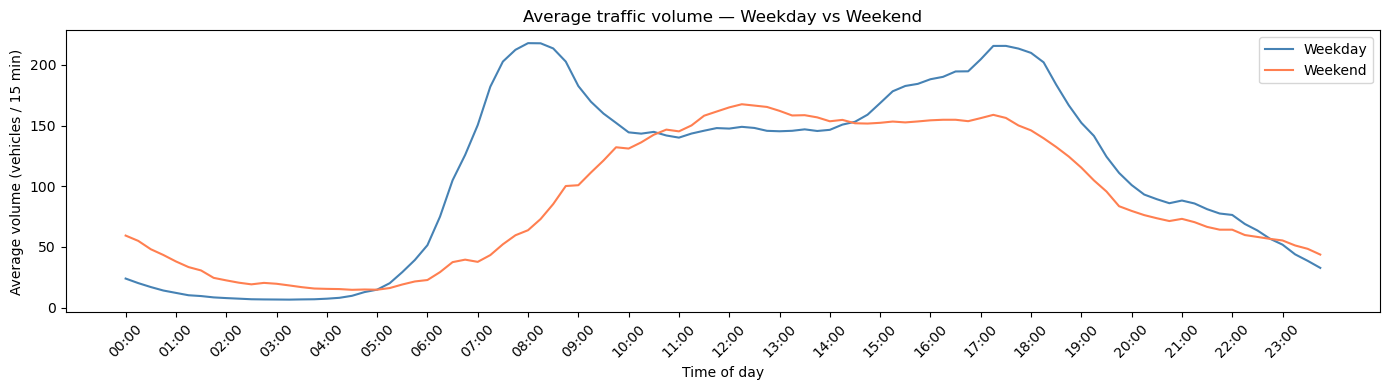

In [25]:
# Average volume by time of day — weekday vs weekend
weekday = df_clean[df_clean['is_weekend'] == 0].groupby('time_index')['Volume'].mean()
weekend = df_clean[df_clean['is_weekend'] == 1].groupby('time_index')['Volume'].mean()

plt.figure(figsize=(14, 4))
plt.plot(weekday.index, weekday.values, label='Weekday', color='steelblue')
plt.plot(weekend.index, weekend.values, label='Weekend', color='coral')
plt.xlabel('Time of day')
plt.ylabel('Average volume (vehicles / 15 min)')
plt.title('Average traffic volume — Weekday vs Weekend')
plt.xticks(range(0, 96, 4), [f'{i//4:02d}:00' for i in range(0, 96, 4)], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## Step 4: Prepare Data for ML Models

Strategy:
- Sliding window approach: use last 12 intervals (3 hours) to predict next interval
- Normalize volume using MinMaxScaler per location to handle different traffic scales
- Features per timestep: Volume, hour, minute, day_of_week, is_weekend, time_index, scats_id, location_id
- Split: 80% train, 20% test (time-based, not random — preserve temporal order)

In [26]:
from sklearn.preprocessing import MinMaxScaler

LOOKBACK = 12  # 12 intervals = 3 hours

# Normalize Volume per location (each location has different traffic scale)
scalers = {}  # save scalers for inverse transform later

df_clean = df_clean.sort_values(['SCATS Number', 'Location', 'Datetime']).reset_index(drop=True)

df_clean['Volume_scaled'] = 0.0

for (scats, loc), group_idx in df_clean.groupby(['SCATS Number', 'Location']).groups.items():
    scaler = MinMaxScaler()
    df_clean.loc[group_idx, 'Volume_scaled'] = scaler.fit_transform(
        df_clean.loc[group_idx, 'Volume'].values.reshape(-1, 1)
    ).flatten()
    scalers[(scats, loc)] = scaler

print(f'Scalers saved: {len(scalers)}')
print(f'\n=== Volume_scaled sample ===')
print(df_clean[['SCATS Number', 'Location', 'Datetime', 'Volume', 'Volume_scaled']].head(10).to_string())

Scalers saved: 138

=== Volume_scaled sample ===
   SCATS Number                         Location            Datetime  Volume  Volume_scaled
0           970  HIGH STREET_RD E of WARRIGAL_RD 2006-10-01 00:00:00      37       0.090909
1           970  HIGH STREET_RD E of WARRIGAL_RD 2006-10-01 00:15:00      30       0.073710
2           970  HIGH STREET_RD E of WARRIGAL_RD 2006-10-01 00:30:00      26       0.063882
3           970  HIGH STREET_RD E of WARRIGAL_RD 2006-10-01 00:45:00      29       0.071253
4           970  HIGH STREET_RD E of WARRIGAL_RD 2006-10-01 01:00:00      14       0.034398
5           970  HIGH STREET_RD E of WARRIGAL_RD 2006-10-01 01:15:00      20       0.049140
6           970  HIGH STREET_RD E of WARRIGAL_RD 2006-10-01 01:30:00      14       0.034398
7           970  HIGH STREET_RD E of WARRIGAL_RD 2006-10-01 01:45:00      10       0.024570
8           970  HIGH STREET_RD E of WARRIGAL_RD 2006-10-01 02:00:00      10       0.024570
9           970  HIGH STREET_RD

In [27]:
import torch

FEATURE_COLS = ['Volume_scaled', 'hour', 'minute', 'day_of_week',
                'is_weekend', 'time_index', 'scats_id', 'location_id']

# Normalize non-volume features globally
from sklearn.preprocessing import StandardScaler

feat_scaler = StandardScaler()
df_clean[['hour', 'minute', 'day_of_week', 'time_index']] = feat_scaler.fit_transform(
    df_clean[['hour', 'minute', 'day_of_week', 'time_index']]
)

# Time-based split FIRST — 80% of days = first 25 days, 20% = last 6 days
all_dates   = sorted(df_clean['Datetime'].dt.normalize().unique())
split_date  = all_dates[int(len(all_dates) * 0.8)]  # ~2006-10-25

print(f'Total days  : {len(all_dates)}')
print(f'Split date  : {split_date.date()}')
print(f'Train period: 2006-10-01 → {split_date.date()}')
print(f'Test period : {split_date.date()} → 2006-10-31')

df_train = df_clean[df_clean['Datetime'] < split_date].copy()
df_test  = df_clean[df_clean['Datetime'] >= split_date].copy()

print(f'\nTrain rows: {len(df_train):,}')
print(f'Test rows : {len(df_test):,}')

Total days  : 31
Split date  : 2006-10-25
Train period: 2006-10-01 → 2006-10-25
Test period : 2006-10-25 → 2006-10-31

Train rows: 317,952
Test rows : 92,736


In [28]:
# Build sequences separately for train and test
# For test: include last LOOKBACK rows of train as context for first test sequences
X_train_list, y_train_list = [], []
X_test_list,  y_test_list  = [], []

for (scats, loc), group in df_clean.groupby(['SCATS Number', 'Location']):
    group = group.sort_values('Datetime').reset_index(drop=True)
    values = group[FEATURE_COLS].values  # (2976, 8)
    datetimes = group['Datetime'].values

    # Find split index within this group
    split_idx = np.searchsorted(datetimes, np.datetime64(split_date))

    # Build train sequences (only from train period)
    for i in range(LOOKBACK, split_idx):
        X_train_list.append(values[i - LOOKBACK:i])
        y_train_list.append(values[i][0])

    # Build test sequences — lookback can reach into train period
    for i in range(split_idx, len(values)):
        if i - LOOKBACK >= 0:
            X_test_list.append(values[i - LOOKBACK:i])
            y_test_list.append(values[i][0])

X_train = np.array(X_train_list, dtype=np.float32)
y_train = np.array(y_train_list, dtype=np.float32)
X_test  = np.array(X_test_list,  dtype=np.float32)
y_test  = np.array(y_test_list,  dtype=np.float32)

print(f'=== Train/Test sequences ===')
print(f'X_train: {X_train.shape}  |  y_train: {y_train.shape}')
print(f'X_test : {X_test.shape}   |  y_test : {y_test.shape}')
print(f'\nTrain sequences cover: 2006-10-01 → {split_date.date()}')
print(f'Test  sequences cover: {split_date.date()} → 2006-10-31')

=== Train/Test sequences ===
X_train: (316296, 12, 8)  |  y_train: (316296,)
X_test : (92736, 12, 8)   |  y_test : (92736,)

Train sequences cover: 2006-10-01 → 2006-10-25
Test  sequences cover: 2006-10-25 → 2006-10-31


In [29]:
# Convert numpy arrays to PyTorch tensors
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train)
X_test_t  = torch.FloatTensor(X_test)
y_test_t  = torch.FloatTensor(y_test)

print('=== PyTorch tensors ready ===')
print(f'X_train_t: {X_train_t.shape}')
print(f'y_train_t: {y_train_t.shape}')
print(f'X_test_t : {X_test_t.shape}')
print(f'y_test_t : {y_test_t.shape}')

=== PyTorch tensors ready ===
X_train_t: torch.Size([316296, 12, 8])
y_train_t: torch.Size([316296])
X_test_t : torch.Size([92736, 12, 8])
y_test_t : torch.Size([92736])


In [30]:
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 64

train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset  = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f'=== DataLoaders ready ===')
print(f'Train batches: {len(train_loader)}')
print(f'Test batches : {len(test_loader)}')
print(f'Batch size   : {BATCH_SIZE}')
print(f'\n✅ Data preparation complete — ready to train!')

=== DataLoaders ready ===
Train batches: 4943
Test batches : 1449
Batch size   : 64

✅ Data preparation complete — ready to train!


## Step 5: Model Definitions

Three models will be implemented and compared:
1. **LSTM** — Long Short-Term Memory
2. **GRU** — Gated Recurrent Unit  
3. **Transformer** — Attention-based model

All models:
- Input : (batch_size, lookback=12, features=8)
- Output: (batch_size, 1) — predicted Volume_scaled of next interval

In [31]:
import torch
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, input_size=8, hidden_size=64, num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        # x: (batch, 12, 8)
        out, _ = self.lstm(x)       # out: (batch, 12, hidden_size)
        out = out[:, -1, :]         # take last timestep: (batch, hidden_size)
        return self.fc(out).squeeze(-1)  # (batch,)

# Test forward pass
model_lstm = LSTMModel()
dummy = torch.randn(64, 12, 8)
out   = model_lstm(dummy)
print(f'LSTM output shape: {out.shape}')
print(f'Total parameters : {sum(p.numel() for p in model_lstm.parameters()):,}')

LSTM output shape: torch.Size([64])
Total parameters : 54,337


In [32]:
class GRUModel(nn.Module):
    def __init__(self, input_size=8, hidden_size=64, num_layers=2, dropout=0.2):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        out, _ = self.gru(x)        # out: (batch, 12, hidden_size)
        out = out[:, -1, :]         # take last timestep: (batch, hidden_size)
        return self.fc(out).squeeze(-1)  # (batch,)

# Test forward pass
model_gru = GRUModel()
out = model_gru(dummy)
print(f'GRU output shape : {out.shape}')
print(f'Total parameters : {sum(p.numel() for p in model_gru.parameters()):,}')

GRU output shape : torch.Size([64])
Total parameters : 41,281


In [33]:
class TransformerModel(nn.Module):
    def __init__(self, input_size=8, d_model=64, nhead=4, 
                 num_layers=2, dropout=0.2):
        super(TransformerModel, self).__init__()
        # Project input features to d_model dimension
        self.input_proj = nn.Linear(input_size, d_model)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=128,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        self.fc = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        x = self.input_proj(x)          # (batch, 12, d_model)
        x = self.transformer(x)         # (batch, 12, d_model)
        x = x[:, -1, :]                 # take last timestep: (batch, d_model)
        return self.fc(x).squeeze(-1)   # (batch,)

# Test forward pass
model_transformer = TransformerModel()
out = model_transformer(dummy)
print(f'Transformer output shape: {out.shape}')
print(f'Total parameters        : {sum(p.numel() for p in model_transformer.parameters()):,}')

Transformer output shape: torch.Size([64])
Total parameters        : 69,633


## Step 6: Training

A shared training function is used for all 3 models.
- Loss     : MSELoss (regression)
- Optimizer: Adam
- Epochs   : 20
- Device   : GPU if available, else CPU

In [34]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

EPOCHS    = 20
LR        = 0.001
DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

def train_model(model, train_loader, test_loader, model_name, 
                epochs=EPOCHS, lr=LR, device=DEVICE):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

    history = {'train_loss': [], 'test_loss': []}

    print(f'\n{"="*50}')
    print(f'Training {model_name}')
    print(f'{"="*50}')

    for epoch in range(1, epochs + 1):
        # --- Train phase ---
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            preds = model(X_batch)
            loss  = criterion(preds, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        # --- Eval phase ---
        model.eval()
        test_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                preds     = model(X_batch)
                test_loss += criterion(preds, y_batch).item()
        test_loss /= len(test_loader)

        scheduler.step(test_loss)
        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)

        if epoch % 5 == 0 or epoch == 1:
            print(f'Epoch {epoch:02d}/{epochs} | '
                  f'Train Loss: {train_loss:.6f} | '
                  f'Test Loss: {test_loss:.6f}')

    print(f'\n✅ {model_name} training complete!')
    print(f'   Final Train Loss: {history["train_loss"][-1]:.6f}')
    print(f'   Final Test Loss : {history["test_loss"][-1]:.6f}')
    return model, history

Using device: cuda


In [35]:
import time

# Reinitialize models fresh before training
model_lstm        = LSTMModel().to(DEVICE)
model_gru         = GRUModel().to(DEVICE)
model_transformer = TransformerModel().to(DEVICE)

results = {}

for model, name in [
    (model_lstm,        'LSTM'),
    (model_gru,         'GRU'),
    (model_transformer, 'Transformer')
]:
    start = time.time()
    trained_model, history = train_model(
        model, train_loader, test_loader, name
    )
    elapsed = time.time() - start
    results[name] = {
        'model'  : trained_model,
        'history': history,
        'time'   : elapsed
    }
    print(f'   Training time: {elapsed:.1f}s')


Training LSTM
Epoch 01/20 | Train Loss: 0.007203 | Test Loss: 0.003349
Epoch 05/20 | Train Loss: 0.003430 | Test Loss: 0.003123
Epoch 10/20 | Train Loss: 0.003165 | Test Loss: 0.003019
Epoch 15/20 | Train Loss: 0.003008 | Test Loss: 0.002980
Epoch 20/20 | Train Loss: 0.002775 | Test Loss: 0.002607

✅ LSTM training complete!
   Final Train Loss: 0.002775
   Final Test Loss : 0.002607
   Training time: 395.6s

Training GRU
Epoch 01/20 | Train Loss: 0.007675 | Test Loss: 0.005543
Epoch 05/20 | Train Loss: 0.003409 | Test Loss: 0.003194
Epoch 10/20 | Train Loss: 0.003180 | Test Loss: 0.002854
Epoch 15/20 | Train Loss: 0.003056 | Test Loss: 0.003072
Epoch 20/20 | Train Loss: 0.002805 | Test Loss: 0.002604

✅ GRU training complete!
   Final Train Loss: 0.002805
   Final Test Loss : 0.002604
   Training time: 380.9s

Training Transformer
Epoch 01/20 | Train Loss: 0.011710 | Test Loss: 0.005703
Epoch 05/20 | Train Loss: 0.004036 | Test Loss: 0.003513
Epoch 10/20 | Train Loss: 0.003689 | Test 

## Step 7: Model Evaluation

Metrics used:
- **MAE** (Mean Absolute Error) — average error in vehicles/15min
- **RMSE** (Root Mean Squared Error) — penalizes large errors more
- **MAPE** (Mean Absolute Percentage Error) — relative error %

All metrics are computed on inverse-transformed values (actual vehicle counts).

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate_model(model, test_loader, model_name, device=DEVICE):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            preds   = model(X_batch).cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(y_batch.numpy())

    all_preds   = np.array(all_preds)
    all_targets = np.array(all_targets)

    # Inverse transform using a representative scaler (global approximation)
    # Use mean of all scalers' scale and min for approximate inverse
    all_mins    = np.array([s.data_min_[0] for s in scalers.values()])
    all_maxs    = np.array([s.data_max_[0] for s in scalers.values()])
    global_min  = all_mins.mean()
    global_max  = all_maxs.mean()
    scale       = global_max - global_min

    preds_actual   = all_preds   * scale + global_min
    targets_actual = all_targets * scale + global_min

    mae  = mean_absolute_error(targets_actual, preds_actual)
    rmse = np.sqrt(mean_squared_error(targets_actual, preds_actual))
    # Avoid division by zero in MAPE
    mask = targets_actual > 1
    mape = np.mean(np.abs((targets_actual[mask] - preds_actual[mask]) 
                           / targets_actual[mask])) * 100

    print(f'=== {model_name} Evaluation ===')
    print(f'MAE  : {mae:.2f}  vehicles/15min')
    print(f'RMSE : {rmse:.2f} vehicles/15min')
    print(f'MAPE : {mape:.2f}%')
    return {'mae': mae, 'rmse': rmse, 'mape': mape,
            'preds': preds_actual, 'targets': targets_actual}

# Evaluate all models
eval_results = {}
for name in ['LSTM', 'GRU', 'Transformer']:
    eval_results[name] = evaluate_model(
        results[name]['model'], test_loader, name
    )
    print()

=== LSTM Evaluation ===
MAE  : 11.48  vehicles/15min
RMSE : 16.58 vehicles/15min
MAPE : 18.48%

=== GRU Evaluation ===
MAE  : 11.49  vehicles/15min
RMSE : 16.57 vehicles/15min
MAPE : 18.84%

=== Transformer Evaluation ===
MAE  : 15.34  vehicles/15min
RMSE : 21.08 vehicles/15min
MAPE : 26.62%



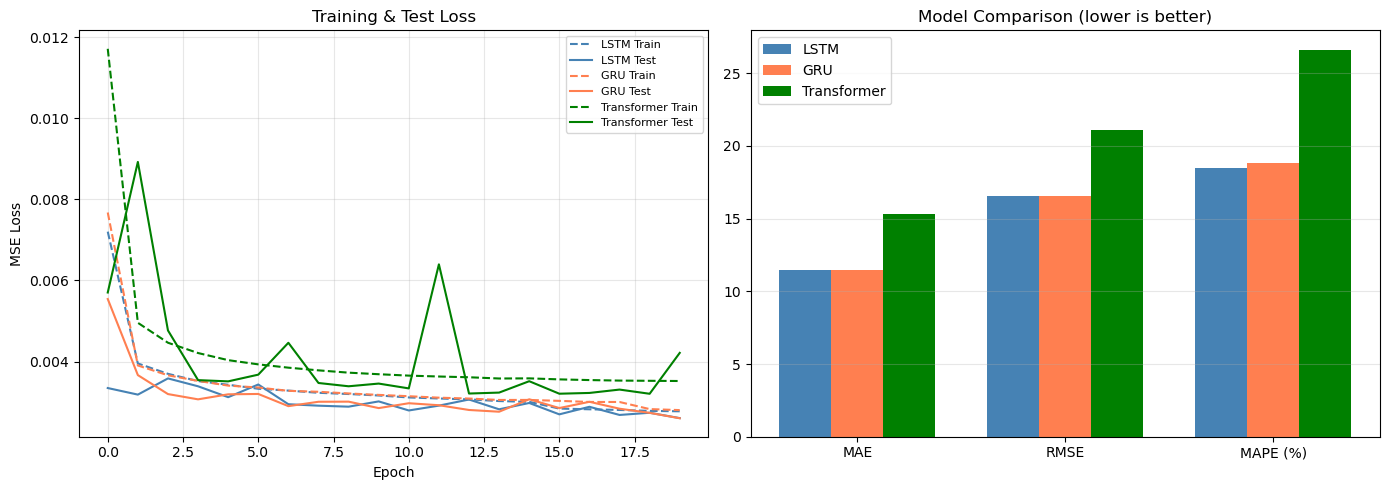

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Loss curves ---
colors = {'LSTM': 'steelblue', 'GRU': 'coral', 'Transformer': 'green'}
for name, res in results.items():
    axes[0].plot(res['history']['train_loss'], 
                 label=f'{name} Train', color=colors[name], linestyle='--')
    axes[0].plot(res['history']['test_loss'],  
                 label=f'{name} Test',  color=colors[name], linestyle='-')
axes[0].set_title('Training & Test Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# --- Metrics bar chart ---
metrics = ['mae', 'rmse', 'mape']
x = np.arange(len(metrics))
width = 0.25
for i, name in enumerate(['LSTM', 'GRU', 'Transformer']):
    vals = [eval_results[name][m] for m in metrics]
    axes[1].bar(x + i * width, vals, width, label=name, color=colors[name])
axes[1].set_title('Model Comparison (lower is better)')
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(['MAE', 'RMSE', 'MAPE (%)'])
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Step 8: Prediction Visualization

Plot predicted vs actual traffic volume for a sample site
to visually assess model performance.

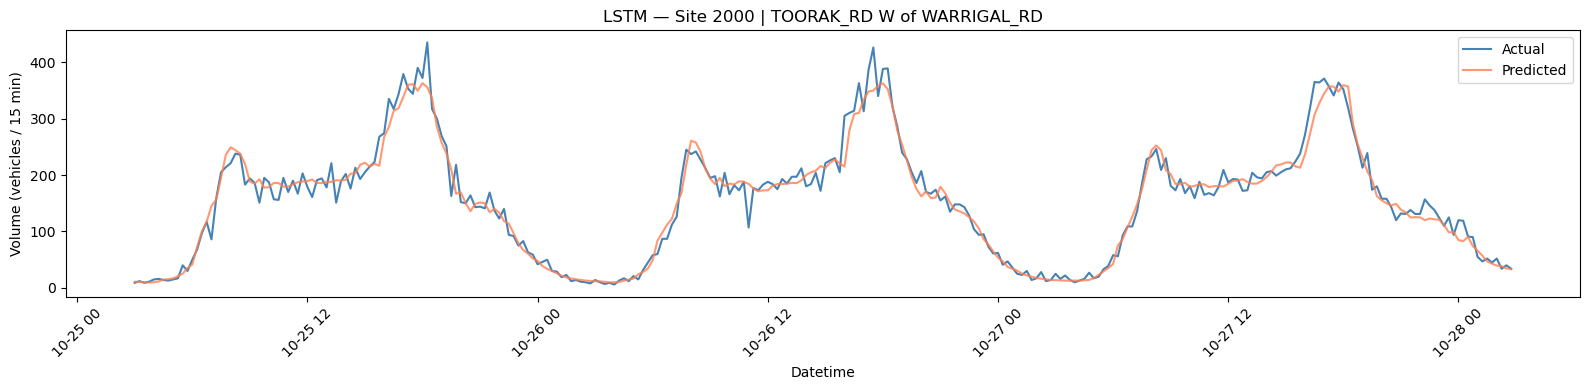

MAE: 13.93 | RMSE: 20.16 vehicles/15min


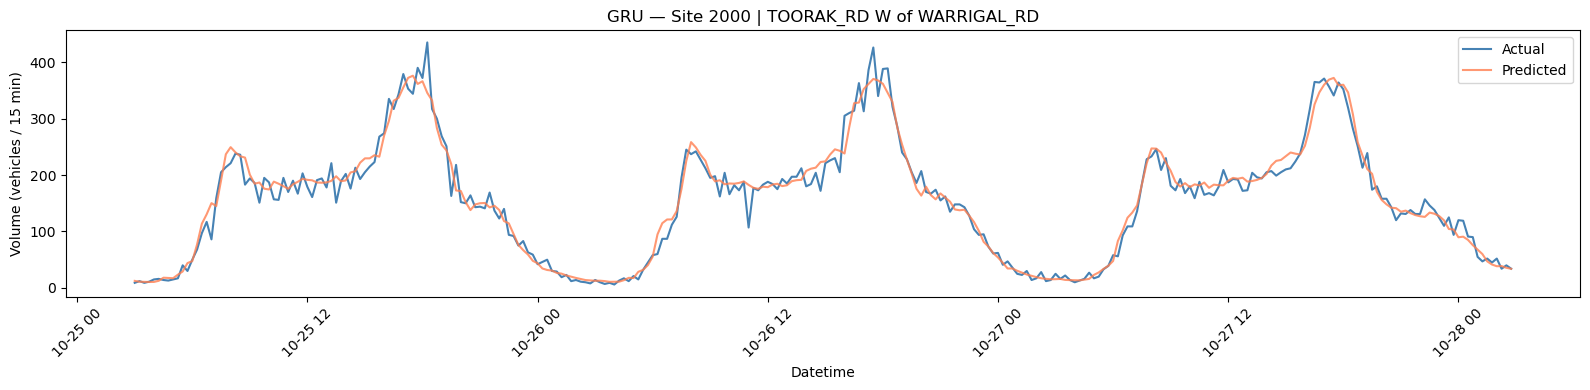

MAE: 13.82 | RMSE: 19.38 vehicles/15min


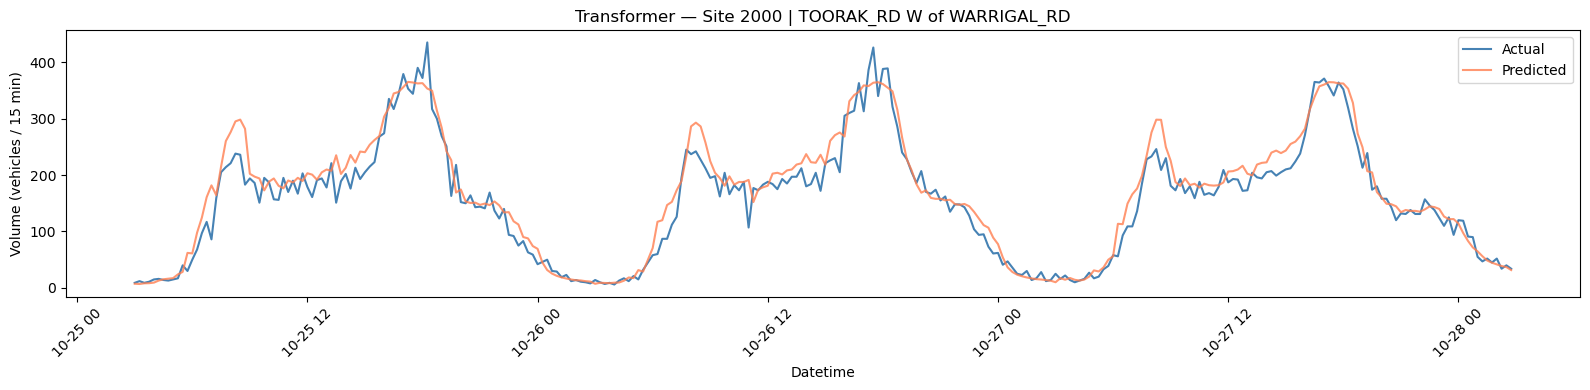

MAE: 20.23 | RMSE: 27.82 vehicles/15min


In [38]:
def plot_predictions(model, model_name, scats_num, location, 
                     n_intervals=96*3, device=DEVICE):
    """
    Plot predicted vs actual volume for a specific site+location
    over n_intervals (default = 3 days = 288 intervals)
    """
    # Get data for this site+location from test period
    mask = (
        (df_clean['SCATS Number'] == scats_num) &
        (df_clean['Location']     == location)  &
        (df_clean['Datetime']     >= split_date)
    )
    site_data = df_clean[mask].sort_values('Datetime').reset_index(drop=True)

    if len(site_data) < LOOKBACK + n_intervals:
        print(f'Not enough data for {scats_num} - {location}')
        return

    scaler = scalers[(scats_num, location)]
    values = site_data[FEATURE_COLS].values

    # Build sequences
    X_site, y_site = [], []
    for i in range(LOOKBACK, LOOKBACK + n_intervals):
        X_site.append(values[i - LOOKBACK:i])
        y_site.append(values[i][0])

    X_site = torch.FloatTensor(np.array(X_site)).to(device)
    y_site = np.array(y_site)

    # Predict
    model.eval()
    with torch.no_grad():
        preds_scaled = model(X_site).cpu().numpy()

    # Inverse transform
    preds_actual  = scaler.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()
    targets_actual = scaler.inverse_transform(y_site.reshape(-1, 1)).flatten()

    # Time axis
    datetimes = site_data['Datetime'].iloc[LOOKBACK:LOOKBACK + n_intervals].values

    # Plot
    plt.figure(figsize=(16, 4))
    plt.plot(datetimes, targets_actual, label='Actual',    color='steelblue', linewidth=1.5)
    plt.plot(datetimes, preds_actual,   label='Predicted', color='coral',     linewidth=1.5, alpha=0.8)
    plt.title(f'{model_name} — Site {scats_num} | {location}')
    plt.xlabel('Datetime')
    plt.ylabel('Volume (vehicles / 15 min)')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    mae  = mean_absolute_error(targets_actual, preds_actual)
    rmse = np.sqrt(mean_squared_error(targets_actual, preds_actual))
    print(f'MAE: {mae:.2f} | RMSE: {rmse:.2f} vehicles/15min')

# Plot all 3 models for same site
SAMPLE_SCATS = 2000
SAMPLE_LOC   = 'TOORAK_RD W of WARRIGAL_RD'

for name in ['LSTM', 'GRU', 'Transformer']:
    plot_predictions(results[name]['model'], name, SAMPLE_SCATS, SAMPLE_LOC)